<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt


TensorFlow version: 2.19.0


This cell imports the necessary libraries for our TensorFlow project:
- `tensorflow as tf`: The core TensorFlow library for building and training machine learning models.
- `tensorflow_hub as hub`: Used for re-using pre-trained model components, though it's not explicitly used in the model definition here, it's a common companion for transfer learning.
- `numpy as np`: A fundamental package for numerical computation in Python, often used for array manipulations.
- `matplotlib.pyplot as plt`: A plotting library used for visualizing data, such as images or training history.

In [5]:
import tensorflow_datasets as tfds

# When 'split' is a list and 'with_info=True', tfds.load returns a tuple:
# (list_of_datasets, ds_info_object)
# We need to unpack this correctly.
all_datasets, ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

# Now, unpack the list of datasets into train_data and val_data
train_data, val_data = all_datasets

This cell is responsible for loading and preparing the `cats_vs_dogs` dataset from TensorFlow Datasets (`tfds`).
- `import tensorflow_datasets as tfds`: Imports the TensorFlow Datasets library.
- `tfds.load(...)`: This function loads the dataset.
  - `'cats_vs_dogs'`: Specifies the dataset name.
  - `split=['train[:80%]', 'train[80%:]']`: Divides the training data into an 80% training set and a 20% validation set.
  - `with_info=True`: Returns a `tfds.core.DatasetInfo` object, which contains metadata about the dataset.
  - `as_supervised=True`: Returns the dataset in a `(image, label)` tuple format, which is convenient for supervised learning tasks.
- `all_datasets, ds_info = ...`: This unpacks the return value. `all_datasets` will be a list containing the two split datasets, and `ds_info` will hold the dataset's metadata.
- `train_data, val_data = all_datasets`: Finally, the two datasets from the `all_datasets` list are unpacked into `train_data` and `val_data` for subsequent use.

In [6]:
IMG_SIZE = 224

def format_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0   # normalize
    return image, label

train_data = train_data.map(format_image).batch(32).prefetch(1)
val_data = val_data.map(format_image).batch(32).prefetch(1)


This cell preprocesses the image data for training and validation.
- `IMG_SIZE = 224`: Defines the target size for all images. Pre-trained models like MobileNetV2 usually expect a specific input size.
- `def format_image(image, label):`: This function takes an image and its label, then performs two crucial preprocessing steps:
  - `tf.image.resize(image, (IMG_SIZE, IMG_SIZE))`: Resizes all images to the `IMG_SIZE` (224x224 pixels) to ensure consistent input for the model.
  - `image = image / 255.0`: Normalizes the pixel values from the original range of [0, 255] to [0.0, 1.0]. This is a common practice that helps neural networks train more effectively.
- `.map(format_image)`: Applies the `format_image` function to each image-label pair in the datasets.
- `.batch(32)`: Groups the preprocessed images into batches of 32. This is important for efficient training.
- `.prefetch(1)`: Optimizes data loading by prefetching the next batch of data while the current batch is being processed by the model, which helps prevent bottlenecks during training.

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze it


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


This cell initializes the pre-trained `MobileNetV2` model, which will serve as the base for our transfer learning approach.
- `base_model = tf.keras.applications.MobileNetV2(...)`:
  - `input_shape=(224,224,3)`: Specifies the expected input image shape (height, width, color channels) for the model.
  - `include_top=False`: This is crucial for transfer learning. It tells Keras to load the MobileNetV2 architecture and weights *without* its original classification head (the 'top' layers). We will add our own custom classification head for cats vs. dogs.
  - `weights='imagenet'`: Loads the weights pre-trained on the ImageNet dataset. These weights have learned to recognize a wide variety of features from a large dataset, which we can leverage for our task.
- `base_model.trainable = False`: This line "freezes" the layers of the `base_model`. This means during the initial training phase, the weights of the MobileNetV2 model will not be updated. This is a common strategy in transfer learning to allow the newly added top layers to learn without disrupting the pre-learned features of the base model.

In [9]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



This cell constructs the full classification model and compiles it for training.
- `model = tf.keras.Sequential([...])`: Defines a sequential Keras model, stacking layers one after another.
  - `base_model`: The frozen pre-trained MobileNetV2 model is the first layer, acting as a feature extractor.
  - `tf.keras.layers.GlobalAveragePooling2D()`: This layer averages the spatial dimensions of the feature maps coming from the `base_model`. It effectively converts the 2D feature maps into a single vector per image, reducing the number of parameters and making the model less prone to overfitting.
  - `tf.keras.layers.Dense(1, activation='sigmoid')`: This is our new classification head. Since it's a binary classification problem (cat or dog), we use a single output neuron with a `sigmoid` activation function. The sigmoid function outputs a probability between 0 and 1, representing the likelihood of the image being a 'dog' (or the positive class).
- `model.compile(...)`: Configures the model for training.
  - `optimizer='adam'`: Specifies the Adam optimizer, a popular choice for deep learning due to its efficiency.
  - `loss='binary_crossentropy'`: Sets the binary cross-entropy loss function, which is standard for binary classification tasks where the output is a probability.
  - `metrics=['accuracy']`: Defines 'accuracy' as the metric to monitor during training, indicating the proportion of correctly classified images.

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 983s 2s/step - accuracy: 0.9753 - loss: 0.0749 - val_accuracy: 0.9837 - val_loss: 0.0443
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 947s 2s/step - accuracy: 0.9851 - loss: 0.0416 - val_accuracy: 0.9839 - val_loss: 0.0416
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 940s 2s/step - accuracy: 0.9865 - loss: 0.0366 - val_accuracy: 0.9852 - val_loss: 0.0412
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.9884 - loss: 0.0334 - val_accuracy: 0.9852 - val_loss: 0.0414
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9896 - loss: 0.0310 - val_accuracy: 0.9856 - val_loss: 0.0418


This cell initiates the first phase of training for the model.
- `history = model.fit(...)`: This function trains the model on the provided data.
  - `train_data`: The preprocessed training dataset.
  - `validation_data=val_data`: The preprocessed validation dataset, used to monitor the model's performance on unseen data during training. This helps detect overfitting.
  - `epochs=5`: The model will iterate over the entire `train_data` 5 times. During these epochs, only the weights of the newly added `Dense` layer (the classification head) will be updated, as the `base_model` was set to `trainable=False`.

In [11]:
model.evaluate(val_data)


146/146 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9856 - loss: 0.0418


[0.04180024564266205, 0.9855976104736328]

This cell evaluates the trained model's performance on the validation dataset.
- `model.evaluate(val_data)`: This function calculates the loss and metrics (in this case, accuracy) of the model on the entire `val_data`.

The output, `[0.04180024564266205, 0.9855976104736328]`, represents:
- The validation loss (approximately 0.0418).
- The validation accuracy (approximately 0.9856 or 98.56%).
This high accuracy suggests that the model is performing very well on unseen data, even with only the top layer trained.

In [12]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=val_data, epochs=3)


Epoch 1/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 3921s 7s/step - accuracy: 0.9569 - loss: 0.1133 - val_accuracy: 0.9785 - val_loss: 0.0685
Epoch 2/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 3847s 7s/step - accuracy: 0.9901 - loss: 0.0355 - val_accuracy: 0.9839 - val_loss: 0.0503
Epoch 3/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 3789s 7s/step - accuracy: 0.9979 - loss: 0.0150 - val_accuracy: 0.9850 - val_loss: 0.0450


This cell performs **fine-tuning**, which is the second phase of transfer learning.
- `base_model.trainable = True`: Here, we unfreeze the `base_model`, allowing its weights to be updated during further training. This enables the pre-trained features to be slightly adjusted to better suit our specific cats vs. dogs dataset.
- `model.compile(...)`: The model is re-compiled after unfreezing the `base_model`. This is necessary for the changes to `trainable` status to take effect.
  - `optimizer=tf.keras.optimizers.Adam(1e-5)`: A crucial step in fine-tuning is to use a **much lower learning rate** (here, `1e-5` or 0.00001) than during the initial training. This prevents large updates that could damage the finely tuned pre-trained weights.
  - `loss='binary_crossentropy'`, `metrics=['accuracy']`: These remain the same as before.
- `model.fit(train_data, validation_data=val_data, epochs=3)`: The model is trained for an additional 3 epochs. Now, both the `base_model`'s weights and the custom classification head's weights are being updated with the very small learning rate.

The output shows that the model continues to improve, with validation accuracy remaining high and the loss continuing to decrease, indicating that fine-tuning further refines the model's performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


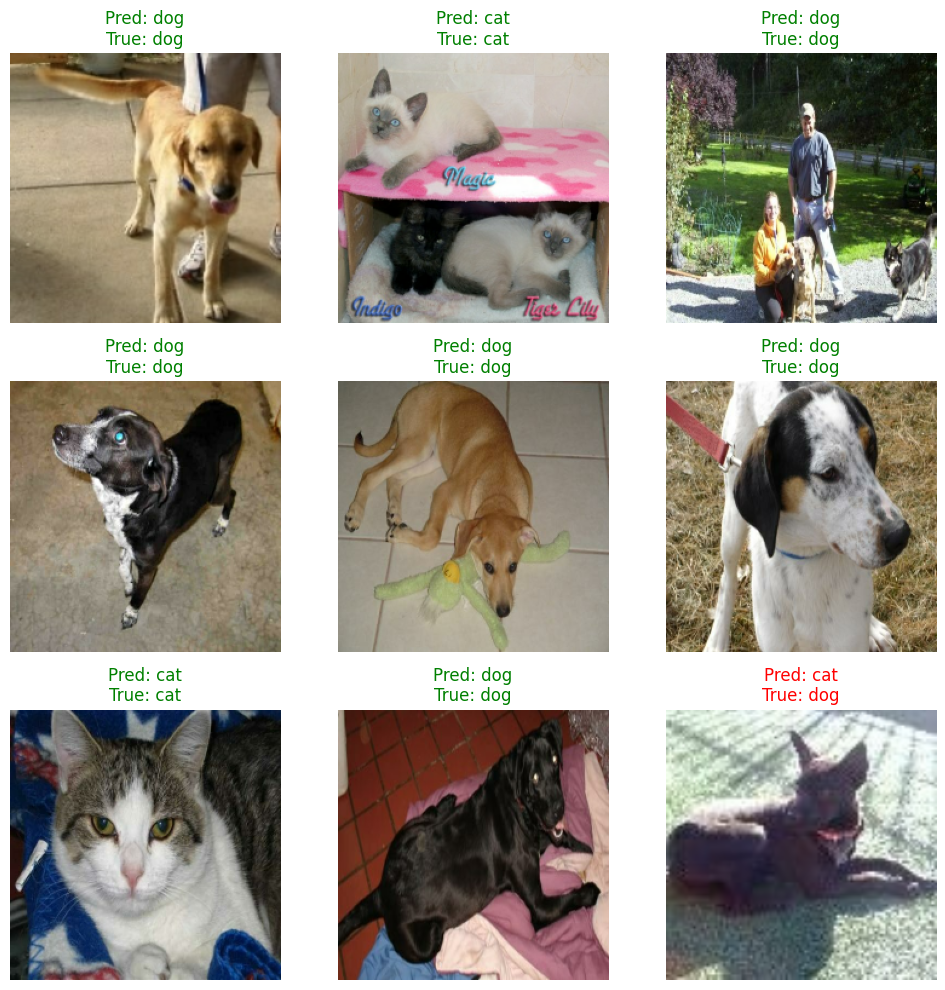

In [13]:
import matplotlib.pyplot as plt

# Get a batch of test images and labels
for image_batch, label_batch in val_data.take(1):
    break

# Make predictions on this batch
predictions = model.predict(image_batch)

# Display a few images with their predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy())

    # Get predicted label (0 for cat, 1 for dog)
    predicted_label = 'dog' if predictions[i] > 0.5 else 'cat'

    # Get true label (0 for cat, 1 for dog)
    true_label = 'dog' if label_batch[i].numpy() == 1 else 'cat'

    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

This cell visualizes the model's predictions on a sample of images from the validation set.
- `import matplotlib.pyplot as plt`: Imports the plotting library.
- `for image_batch, label_batch in val_data.take(1): break`: Retrieves a single batch of images and their true labels from the `val_data` for testing.
- `predictions = model.predict(image_batch)`: The trained `model` makes predictions on this batch of images.
- `plt.figure(figsize=(10, 10))`: Creates a figure to display the images.
- The `for i in range(9):` loop iterates through the first 9 images in the batch:
  - `plt.imshow(image_batch[i].numpy())`: Displays the image.
  - `predicted_label = 'dog' if predictions[i] > 0.5 else 'cat'`: Converts the model's output probability (which is between 0 and 1) into a 'cat' or 'dog' label. If the probability is > 0.5, it's classified as a dog; otherwise, a cat.
  - `true_label = 'dog' if label_batch[i].numpy() == 1 else 'cat'`: Converts the numerical true label (0 or 1) into 'cat' or 'dog'.
  - `color = 'green' if predicted_label == true_label else 'red'`: Sets the title color to green for correct predictions and red for incorrect ones.
  - `plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)`: Adds a title to each image showing the predicted and true labels.
  - `plt.axis("off")`: Hides the axes for cleaner image display.
- `plt.tight_layout()`: Adjusts subplot parameters for a tight layout.
- `plt.show()`: Displays the generated plot.

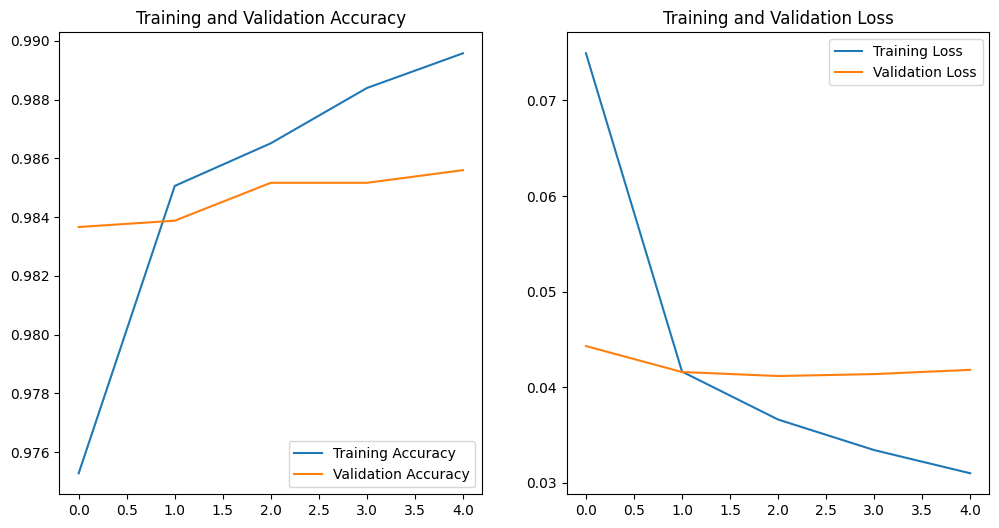

In [14]:
import matplotlib.pyplot as plt

# Get training history data from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

This cell visualizes the training and validation accuracy and loss over the epochs.
- The left plot shows `Training Accuracy` and `Validation Accuracy`.
- The right plot shows `Training Loss` and `Validation Loss`.

These plots help in understanding if the model is overfitting (training accuracy much higher than validation accuracy) or underfitting (both training and validation accuracy are low), and how well the model is generalizing to unseen data.

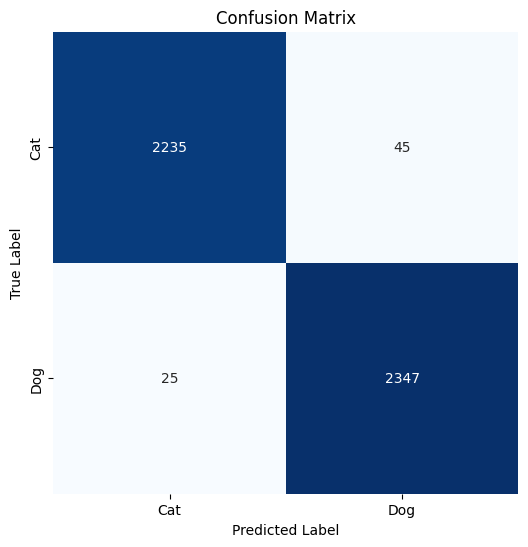

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Initialize lists to store true labels and predictions
all_true_labels = []
all_predictions = []

# Iterate through the entire validation dataset
for image_batch, label_batch in val_data:
    predictions_batch = model.predict(image_batch, verbose=0)
    all_predictions.extend(predictions_batch.flatten())
    all_true_labels.extend(label_batch.numpy())

# Convert to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predictions = np.array(all_predictions)

# Convert probabilities to binary predictions (0 or 1)
binary_predictions = (all_predictions > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(all_true_labels, binary_predictions)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

This cell generates and displays a confusion matrix for your model's performance on the entire validation dataset.
- `from sklearn.metrics import confusion_matrix`: Imports the necessary function to compute the confusion matrix.
- `import seaborn as sns`: Imports Seaborn for enhanced data visualization.
- The code then iterates through `val_data` to collect all true labels and the model's predictions for each image.
- `binary_predictions = (all_predictions > 0.5).astype(int)`: Converts the model's output probabilities (0 to 1) into hard binary predictions (0 for cat, 1 for dog) using a threshold of 0.5.
- `cm = confusion_matrix(all_true_labels, binary_predictions)`: Computes the confusion matrix, which is a table showing the number of correct and incorrect predictions made by the classification model compared to the actual outcomes (true labels).
- The `sns.heatmap(...)` function visualizes this matrix:
  - The x-axis represents the predicted labels, and the y-axis represents the true labels.
  - The numbers in each cell indicate:
    - **Top-left:** True Negatives (correctly predicted cats).
    - **Top-right:** False Positives (incorrectly predicted dogs, were actually cats).
    - **Bottom-left:** False Negatives (incorrectly predicted cats, were actually dogs).
    - **Bottom-right:** True Positives (correctly predicted dogs).

This visualization helps you quickly understand your model's strengths and weaknesses regarding false positives and false negatives.